# Milestone 1

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

c:\Users\alapr\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data=pd.read_csv("data\\financial_loan.csv")

In [3]:
data.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [21]:
data.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

## Opis kolumn
- id - identyfikator klienta/wniosku
- address_state - stan zamieszkania
- application_type - typ aplikacji **(zawiera tylko wartość INDIVIDUAL)**
- emp_length - długość zatrudnienia w latach
- emp_title - stanowisko prcay
- grade - ocena kredytowa **(A-G im wyższa tym lepiej)**
- home_ownership - status posiadania domu **(RENT, MORTAGE, OWN, OTHER, NONE)**
- issue_date - data wydania pożyczki
- last_credit_pull_date - data ostatniego sprawdzenia historii kredytowej
- last_payment_date - data ostatniej wpłaty na pożyczkę
- loan_status - status pożyczki **(Fully_Paid, Charged Off, Current)**
- next_payment_date - planowana data następnej wpłaty
- member_id - identyfikator klienta
- purpose - cel pożyczki **(13 kategorii plus other)**
- sub_grade - podkategoria oceny kredytowej **(bardziej dokładna niż grade, typu A1, A2, ...)**
- term - okres spłaty pożyczki **(36 months, 60 months)**
- verification_status - status weryfikacji dochodu klienta **(Not Verified, Verified, Source Verified)**
- annual_income - roczny dochód klienta
- dti (dent-to-income-ratio) - wskaźnik zadłużenia do dochodu
- installment - miesięczna rata
- int_rate - oprocentowanie
- loan_amount - kwota pożyczki
- total_acc - łączna liczba kont kredytowych klienta'
- total_payment - łączna suma spłat dokonanych przez klienta

## Cel biznesowy 
- Możliwość dostosowania produktów kredytowych do konkretnych grup klientów. (dłuższy termin spłaty itp.)
- Wykrywanie wzorców niespłacania i poprawa procesów windykacyjnych przez zrozumienie charakterystyk klastrów o wysokim ryzyku.
- Zrozumienie czynników wpływających na spłacalność (zmienne różnicujące klastry).

## Analiza 

In [5]:
data.info() #none pojawia się w kolumnie emp_title

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

In [6]:
data.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


In [19]:
data.nunique()

address_state            50
emp_length               11
grade                     7
home_ownership            5
loan_status               3
purpose                  14
sub_grade                35
term                      2
verification_status       3
annual_income          5090
dti                    2863
int_rate                371
loan_amount             794
total_acc                49
is_employed               2
issue_month              12
issue_day                13
date_diff               251
dtype: int64

In [8]:
columns = ['application_type', 'emp_length',
       'grade', 'home_ownership', 'loan_status',
       'purpose', 'sub_grade', 'term', 'verification_status']
for col in columns:
    print(f"Unique values in {col}:")
    print(data[col].value_counts())
    print("\n")

Unique values in application_type:
application_type
INDIVIDUAL    38576
Name: count, dtype: int64


Unique values in emp_length:
emp_length
10+ years    8870
< 1 year     4575
2 years      4382
3 years      4088
4 years      3428
5 years      3273
1 year       3229
6 years      2228
7 years      1772
8 years      1476
9 years      1255
Name: count, dtype: int64


Unique values in grade:
grade
B    11674
A     9689
C     7904
D     5182
E     2786
F     1028
G      313
Name: count, dtype: int64


Unique values in home_ownership:
home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64


Unique values in loan_status:
loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64


Unique values in purpose:
purpose
Debt consolidation    18214
credit card            4998
other                  3824
home improvement       2876
major purchase         2110
small business         177

Czy loan_status można zamienić z 3 na 2 kategorie?
```
Unique values in loan_status:
loan_status
Fully Paid     32145
Charged Off     5333
Current         1098 
```

In [3]:
mask = data['emp_title'].map(data['emp_title'].value_counts()) > 34
data.loc[mask, 'emp_title'].value_counts()

emp_title
US Army                    135
Bank of America            109
IBM                         67
AT&T                        63
Wells Fargo                 57
Kaiser Permanente           56
USAF                        55
UPS                         52
US Air Force                52
Walmart                     45
Lockheed Martin             44
United States Air Force     42
State of California         42
U.S. Army                   42
Verizon Wireless            41
Self Employed               40
USPS                        40
US ARMY                     39
Walgreens                   38
JP Morgan Chase             38
US Navy                     37
Department of Defense       36
JPMorgan Chase              36
Target                      35
Self                        35
Name: count, dtype: int64

In [10]:
sum(data['emp_title'].value_counts()==1) #tyle nazw stanowisk pojawia się tylko raz

25309

In [11]:
np.divide(data['emp_title'].isnull().sum(), data['emp_title'].count()) #braki danych prawie 4%


np.float64(0.038720448058592274)

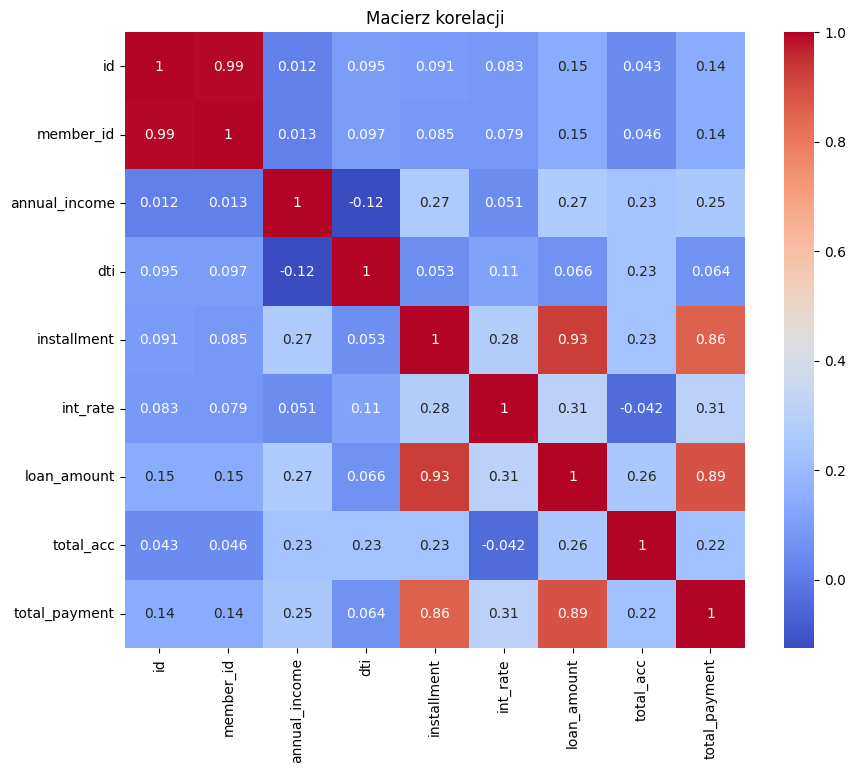

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Macierz korelacji')
plt.show()


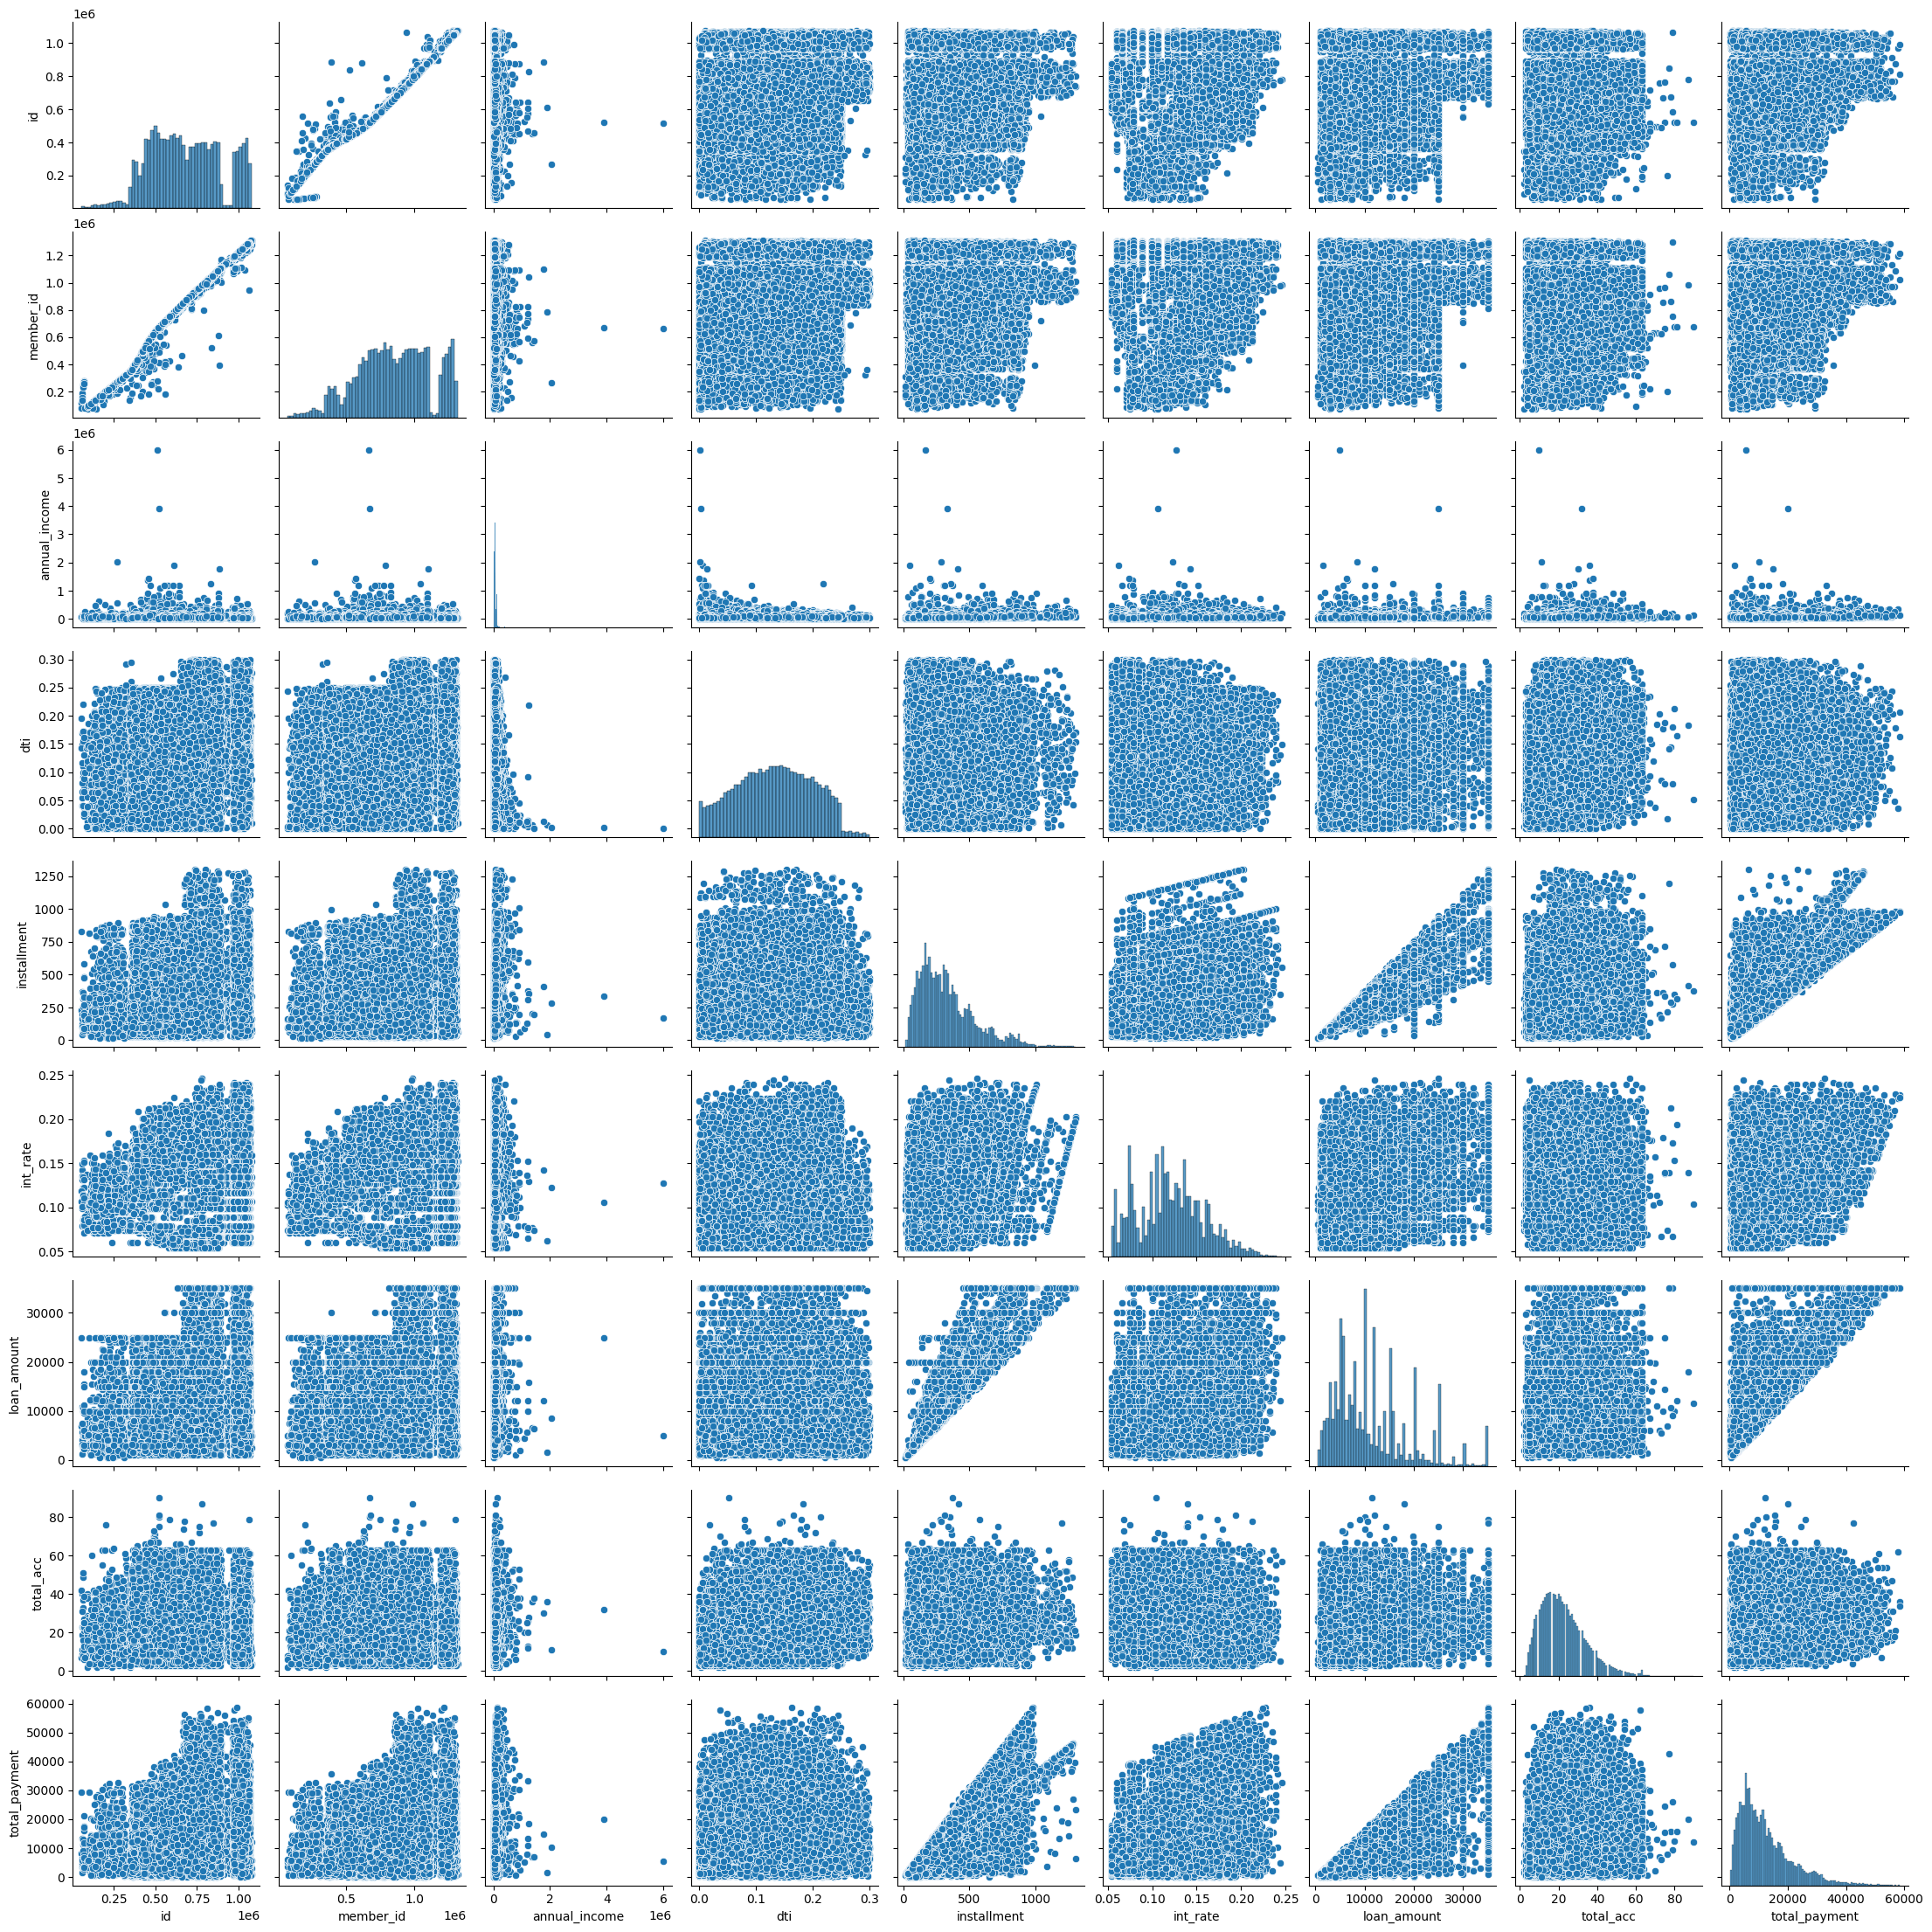

In [13]:
sns.pairplot(data)
plt.show()

- Może można pogrupować nazwy ('emp_title') na rodzaje stanowisk, aby zawężyć ilość kategorii. Podobnie można pomyśleć nad grupowaniem w kolumnie purpose.
- kolumny id, member_id, application_type - do usunięcia
- z kolumn installment, total_payment, loan_amount usunąć installment, kóre jest mocno skorelowane z pozostałymi dwoma
- kodowanie zmiennych nie numerycznych
- wartości none w kolumnie emp_tile stanowią 4%
- w kolumnie home_ovnership 3 obserwacje przyisane do kategorii NONE, która raczej nie jest brakiem danych

## Usuwanie kolumn

In [3]:
data = data.drop(['id', 'member_id', 'application_type'], axis=1)

In [5]:
data.columns

Index(['address_state', 'emp_length', 'emp_title', 'grade', 'home_ownership',
       'issue_date', 'last_credit_pull_date', 'last_payment_date',
       'loan_status', 'next_payment_date', 'purpose', 'sub_grade', 'term',
       'verification_status', 'annual_income', 'dti', 'installment',
       'int_rate', 'loan_amount', 'total_acc', 'total_payment'],
      dtype='object')

Ograniczenie ilości zmiennych i usunięcie zmiennych mocno skorelowanymi z innymi zmiennymi. 

In [4]:
data = data.drop(['installment', 'total_payment'], axis=1) #TODO ważne do późniejszego testowania

Ponieważ większość stanowisk pojawia się tylko raz to pokazuje, że nie da się nic wywnioskować z tytułu pracy - ale możemy sprawdzać czy ktoś w ogóle pracuje

In [5]:
data['is_employed'] = np.where(data['emp_title'].isnull(), 0, 1)
data = data.drop('emp_title', axis=1)
data.head()


,address_state,emp_length,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,next_payment_date,purpose,sub_grade,term,verification_status,annual_income,dti,int_rate,loan_amount,total_acc,is_employed
0,GA,< 1 year,C,RENT,11-02-2021,13-09-2021,13-04-2021,Charged Off,13-05-2021,car,C4,60 months,Source Verified,30000.0,0.0100,0.1527,2500,4,1
1,CA,9 years,E,RENT,01-01-2021,14-12-2021,15-01-2021,Fully Paid,15-02-2021,car,E1,36 months,Source Verified,48000.0,0.0535,0.1864,3000,4,1
2,CA,4 years,C,RENT,05-01-2021,12-12-2021,09-01-2021,Charged Off,09-02-2021,car,C5,36 months,Not Verified,50000.0,0.2088,0.1596,12000,11,1
3,TX,< 1 year,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,Fully Paid,12-04-2021,car,B2,60 months,Source Verified,42000.0,0.0540,0.1065,4500,9,1
4,IL,10+ years,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,Fully Paid,15-02-2021,car,A1,36 months,Verified,83000.0,0.0231,0.0603,3500,28,1


## Typy kolumn (przygotowanie do kodowania zmiennych)

Zmienne kategoryczne: (one hot encoding z pominięciem jednej kolumny, zgrupowanie mniej popularnych kategorii do kategorii other, podział tematyczny na bardziej ogólne grupy)
- verification_status
- purpose
- loan_status
- address_state
- home_ownership

Zmienne porządkowe: (ordinal encoding + normalizacjia, label encoding)
- emp_length
- grade
- sub_grade

Zmienne binarne: (binary encoding) 
- term
- is_employed

Zmienne numeryczne: (winsoryzacja, normalizacja)
- annual_income
- dti
- int_rate
- loan_amount
- total_acc

Zmienne reprezentujące daty:
- issue_date
- last_credit_pull_date
- last_payment_date
- next_payment_date

Dla dat możliwość liczenia odległości pomiędzy różnymi datami lub stworzenie zmiennych typu pora roku, kwartał, tydzień roku, dzień tygodnia, czy jest to weekend lub inne możliwie istotne dla tematu.

In [18]:
data.nunique()

address_state              50
emp_length                 11
grade                       7
home_ownership              5
issue_date                 65
last_credit_pull_date     107
last_payment_date         102
loan_status                 3
next_payment_date         102
purpose                    14
sub_grade                  35
term                        2
verification_status         3
annual_income            5096
dti                      2863
int_rate                  371
loan_amount               880
total_acc                  82
is_employed                 2
dtype: int64

In [19]:
# data['emp_title'].value_counts()

In [20]:
# import re

# def normalize_text(text):
#     text = str(text)
#     # Zamiana na małe litery
#     text = text.lower()
#     # Usunięcie znaków specjalnych (wszystko, co nie jest literą lub spacją)
#     text = re.sub(r'[^a-z\s]', '', text)
#     # Usunięcie nadmiarowych spacji
#     text = re.sub(r'\s+', ' ', text).strip()
#     return text

In [21]:
# data['normalized_job_title'] = data['emp_title'].apply(normalize_text)

O tyle ograniczono ilośc unikalnych zmiennych zmiennej dyskretnej.

In [22]:
# data['emp_title'].nunique() - data['normalized_job_title'].nunique()

In [23]:
# import nltk
# from nltk.corpus import stopwords

# # Pobierz listę stop words (tylko za pierwszym razem)
# nltk.download('stopwords')

# stop_words = set(stopwords.words('english'))

# def remove_stop_words(text):
#     words = text.split()
#     filtered_words = [word for word in words if word.lower() not in stop_words]
#     return ' '.join(filtered_words)

In [24]:
# data['normalized_job_title2'] = data['emp_title'].apply(normalize_text).apply(remove_stop_words)

In [25]:
# data['emp_title'].nunique() - data['normalized_job_title2'].nunique()

Dodatkowo zmniejszono liczbę unikalnych grup o 206

In [26]:
# import pandas as pd
# pd.set_option('display.max_rows', None)  
# print(data['normalized_job_title'].value_counts())

### Pozbycie się outlierów i normalizacja

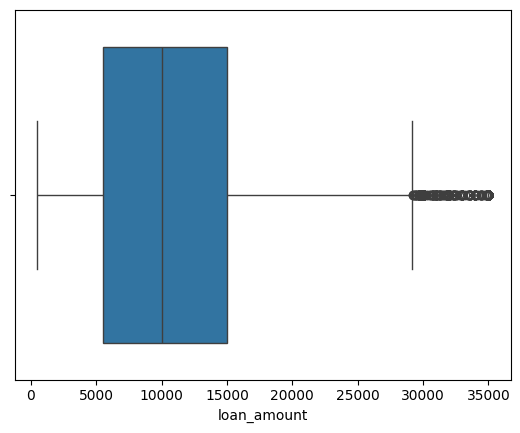

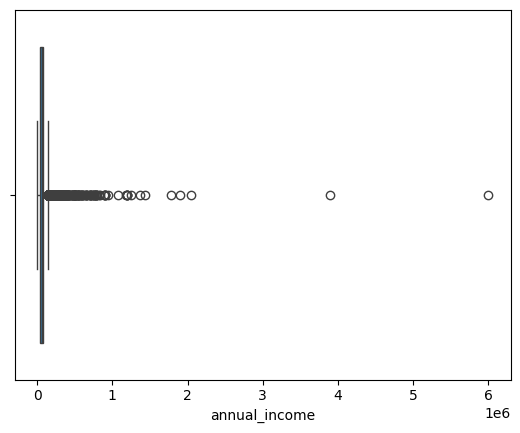

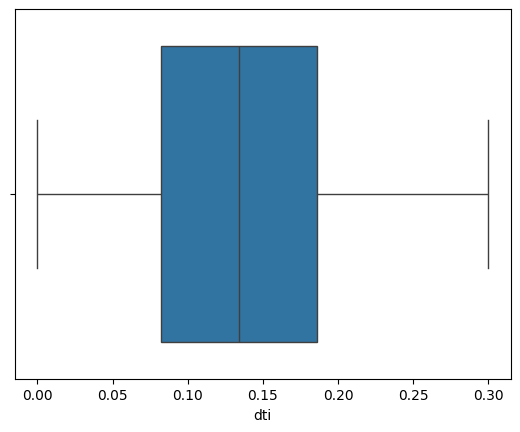

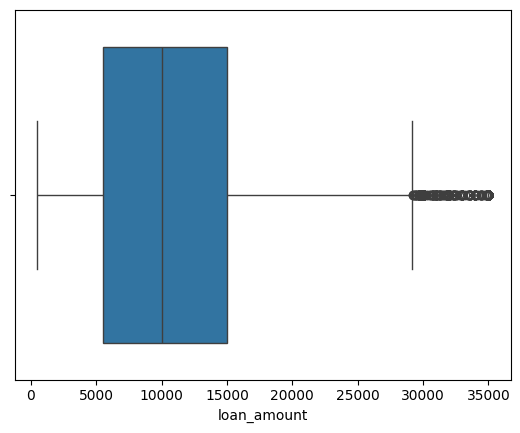

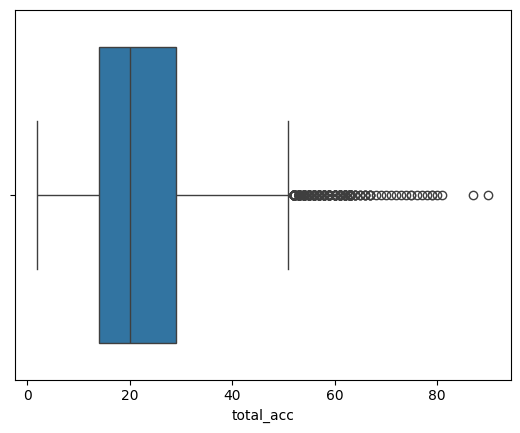

In [8]:
sns.boxplot(x=data['loan_amount'])
plt.show()
sns.boxplot(x=data['annual_income'])
plt.show()
sns.boxplot(x=data['dti'])
plt.show()
sns.boxplot(x=data['loan_amount'])
plt.show()
sns.boxplot(x=data['total_acc'])
plt.show()


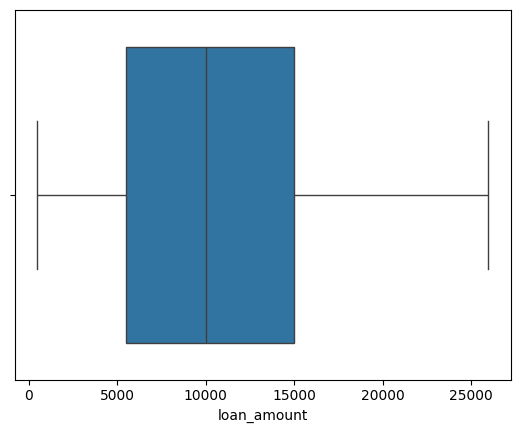

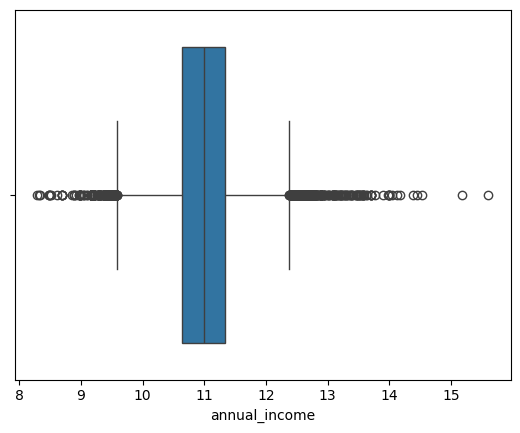

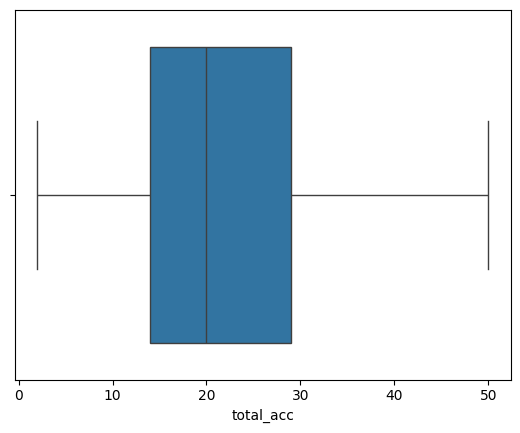

In [9]:

data['loan_amount'] = winsorize(data['loan_amount'], limits=[0, 0.04])
sns.boxplot(x=data['loan_amount'])
plt.show()
data['annual_income'] = np.log1p(data['annual_income'])
sns.boxplot(x=data['annual_income'])
plt.show()
data['total_acc'] = winsorize(data['total_acc'], limits=[0, 0.02])
sns.boxplot(x=data['total_acc'])
plt.show()


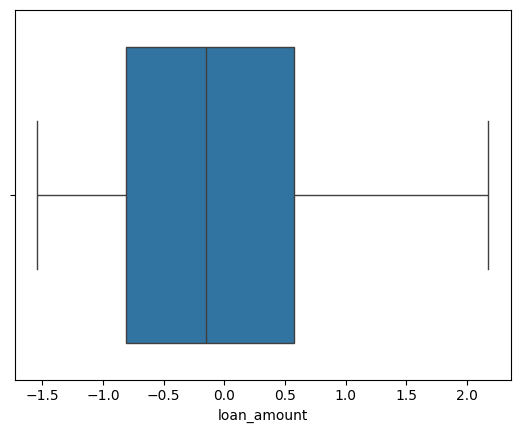

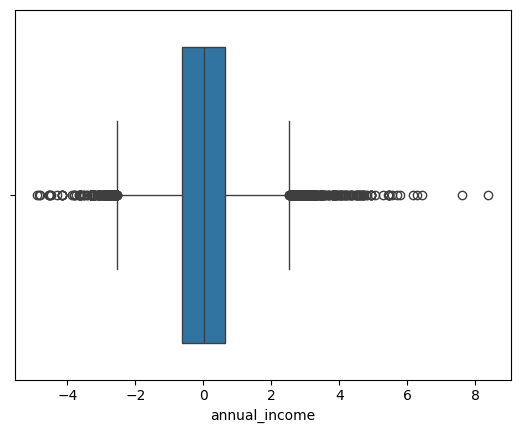

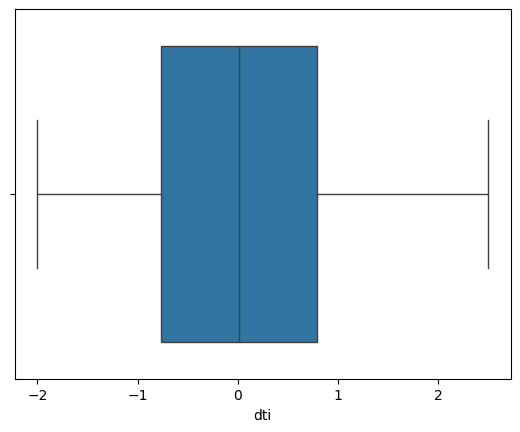

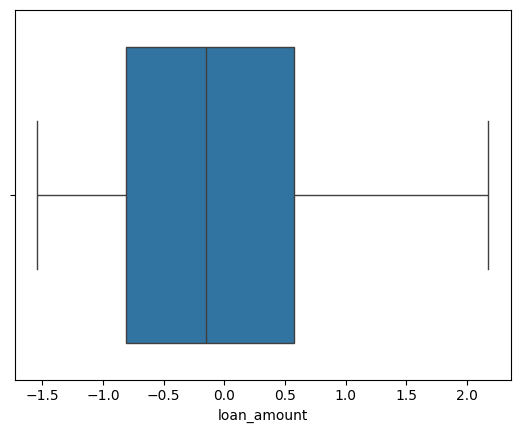

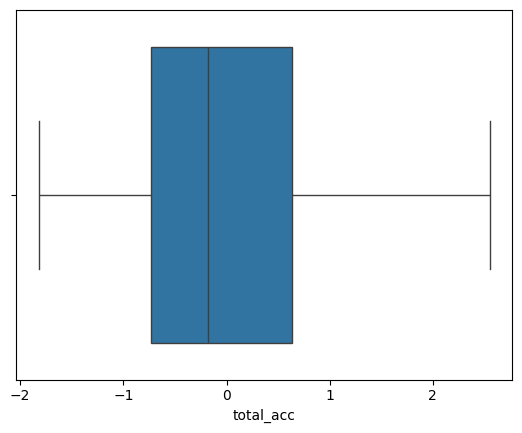

In [10]:
numeric_cols = data.select_dtypes(include=['int64', 'float64', 'int32']).columns
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
sns.boxplot(x=data['loan_amount'])
plt.show()
sns.boxplot(x=data['annual_income'])
plt.show()
sns.boxplot(x=data['dti'])
plt.show()
sns.boxplot(x=data['loan_amount'])
plt.show()
sns.boxplot(x=data['total_acc'])
plt.show()

### Przetwarzanie dat

In [11]:
date_cols = ['issue_date', 'last_credit_pull_date', 'last_payment_date', 'next_payment_date']
for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce', dayfirst=True)

data['issue_month'] = data['issue_date'].dt.month
data['issue_day'] = data['issue_date'].dt.day
# data['issue_year'] = data['issue_date'].dt.year -- jest tylko 1


In [12]:
dd = data['last_credit_pull_date']-data['issue_date']
dd_diff=[]
for i in dd:
    dd_diff.append(float(str(i).split(" ")[0]))
data['date_diff']=pd.Series(dd_diff) #różnica dni pomiędzy wydaniem kredytu a sprawdzeniem historii kredytowej

data['date_diff'] = data['date_diff'].astype(float)

data['date_diff'] = scaler.fit_transform(data[['date_diff']])


In [13]:

data = data.drop(['issue_date', 'last_credit_pull_date', 'last_payment_date', 'next_payment_date'], axis=1)
print(data['issue_month'].unique())
print(data['issue_day'].unique())


[ 2  1  7 11  6  9  8 12 10  5  3  4]
[11  1  5 25 17 19  2  9 22 12  7  8 10]


## Kodowanie zmiennych

In [17]:
data.head()

,address_state,emp_length,grade,home_ownership,loan_status,purpose,sub_grade,term,verification_status,annual_income,dti,int_rate,loan_amount,total_acc,is_employed,issue_month,issue_day,date_diff
0,GA,< 1 year,C,RENT,Charged Off,car,C4,60 months,Source Verified,-0.616624,-1.849281,0.866753,-1.178995,-1.591672,0.196775,2,11,1.961898
1,CA,9 years,E,RENT,Fully Paid,car,E1,36 months,Source Verified,-0.336655,-1.196722,1.773553,-1.111977,-1.591672,0.196775,1,1,2.999245
2,CA,4 years,C,RENT,Charged Off,car,C5,36 months,Not Verified,-0.305548,1.132987,1.052418,0.094353,-0.977213,0.196775,1,5,2.952447
3,TX,< 1 year,B,MORTGAGE,Fully Paid,car,B2,60 months,Source Verified,-0.429978,-1.189222,-0.376398,-0.910922,-1.152773,0.196775,2,25,2.554668
4,IL,10+ years,A,MORTGAGE,Fully Paid,car,A1,36 months,Verified,0.207729,-1.652763,-1.619548,-1.044958,0.515045,0.196775,1,1,2.999245


In [14]:
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
emp_length_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', 
                    '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years']

ord_encoder = OrdinalEncoder(categories=[emp_length_order, grade_order, sorted(data['sub_grade'].dropna().unique())])
data[['emp_length', 'grade', 'sub_grade']] = ord_encoder.fit_transform(data[['emp_length', 'grade', 'sub_grade']])


In [15]:
columns = ['home_ownership', 'loan_status',
       'purpose', 'verification_status', 'purpose']
for col in columns:
    print(f"Unique values in {col}:")
    print(data[col].value_counts())
    print("\n")

Unique values in home_ownership:
home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64


Unique values in loan_status:
loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64


Unique values in purpose:
purpose
Debt consolidation    18214
credit card            4998
other                  3824
home improvement       2876
major purchase         2110
small business         1776
car                    1497
wedding                 928
medical                 667
moving                  559
house                   366
vacation                352
educational             315
renewable_energy         94
Name: count, dtype: int64


Unique values in verification_status:
verification_status
Not Verified       16464
Verified           12335
Source Verified     9777
Name: count, dtype: int64


Unique values in purpose:
purpose
Debt consolidation    18214
credit card            4

In [16]:
top_states = data['address_state'].value_counts().nlargest(38).index
data['address_state_grouped'] = data['address_state'].apply(lambda x: x if x in top_states else 'Other')
data = pd.get_dummies(data, columns=['address_state_grouped'], drop_first=True)

data = data.drop('address_state', axis=1)

In [17]:
cat_cols = ['verification_status', 'loan_status', 'home_ownership', 'purpose']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [18]:
data['term'] = data['term'].astype(str).str.strip()
data['60_month_term'] = np.where(data['term'] == '60 months', 1, 0)
data = data.drop('term', axis=1)


In [35]:
data.head()

,emp_length,grade,sub_grade,annual_income,dti,int_rate,loan_amount,total_acc,is_employed,issue_month,...,purpose_house,purpose_major purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small business,purpose_vacation,purpose_wedding,60_month_term
0,0.0,2.0,13.0,-1.227716,-1.849281,0.866753,-1.249637,-1.638577,0.196775,2,...,0,0,0,0,0,0,0,0,0,1
1,9.0,4.0,20.0,-0.375292,-1.196722,1.773553,-1.176650,-1.638577,0.196775,1,...,0,0,0,0,0,0,0,0,0,0
2,4.0,2.0,14.0,-0.301255,1.132987,1.052418,0.137112,-1.001180,0.196775,1,...,0,0,0,0,0,0,0,0,0,0
3,0.0,1.0,6.0,-0.617473,-1.189222,-0.376398,-0.957690,-1.183294,0.196775,2,...,0,0,0,0,0,0,0,0,0,1
4,10.0,0.0,0.0,0.617947,-1.652763,-1.619548,-1.103663,0.546784,0.196775,1,...,0,0,0,0,0,0,0,0,0,0


## Visualization

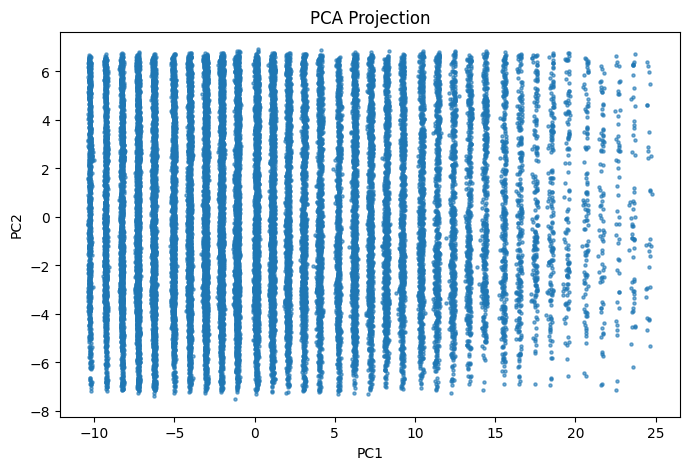

In [19]:
X = data.select_dtypes(include=[float, int])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.6)
plt.title('PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

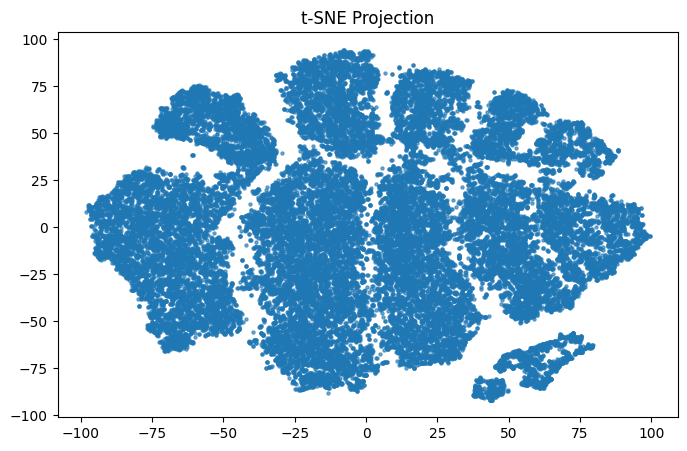

In [20]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=5, alpha=0.6)
plt.title('t-SNE Projection')
plt.show()

c:\Users\alapr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\alapr\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


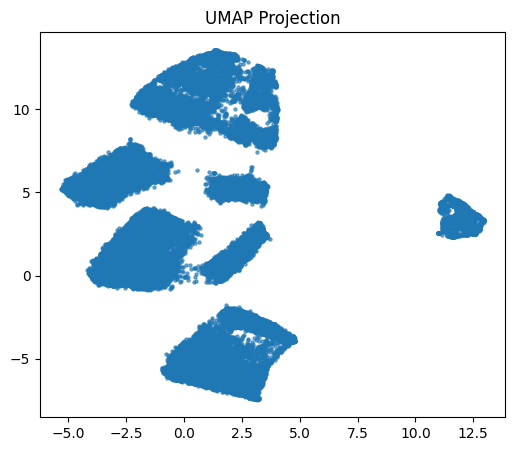

In [33]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)
plt.figure(figsize=(6,5))
plt.scatter(X_umap[:,0], X_umap[:,1], s=5, alpha=0.6)
plt.title('UMAP Projection')
plt.show()

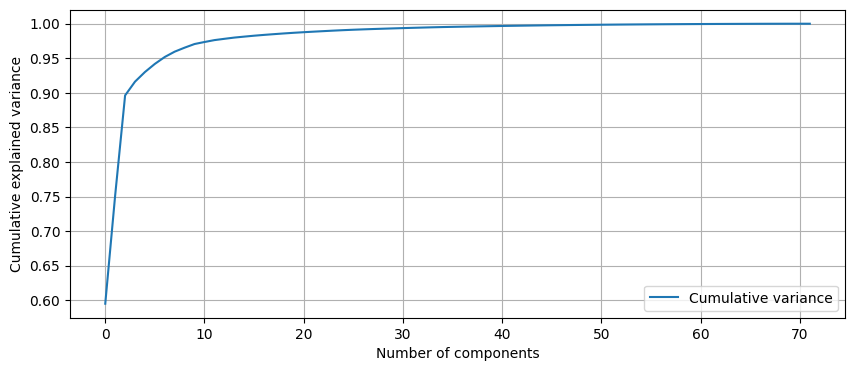

In [21]:
pca = PCA(n_components=X.shape[1], random_state=42)
pca.fit(X)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(cum_var, label='Cumulative variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.grid(True)
plt.show()

Najważniejsze cechy dla każdego komponentu:

PC1 (wyjaśnia 5.2% wariancji):
  int_rate: 0.889
  sub_grade: 0.883
  grade: 0.874
  60_month_term: 0.654
  loan_amount: 0.569

PC2 (wyjaśnia 3.2% wariancji):
  total_acc: 0.640
  home_ownership_RENT: 0.615
  annual_income: 0.592
  emp_length: 0.457
  loan_amount: 0.436

PC3 (wyjaśnia 2.5% wariancji):
  issue_month: 0.842
  date_diff: 0.842
  loan_status_Current: 0.323
  loan_status_Fully Paid: 0.238
  annual_income: 0.163

PC4 (wyjaśnia 2.2% wariancji):
  verification_status_Source Verified: 0.499
  issue_day: 0.445
  verification_status_Verified: 0.376
  loan_status_Current: 0.321
  home_ownership_RENT: 0.301

PC5 (wyjaśnia 2.0% wariancji):
  issue_day: 0.487
  home_ownership_OWN: 0.400
  home_ownership_RENT: 0.368
  dti: 0.357
  purpose_credit card: 0.317

PC6 (wyjaśnia 1.8% wariancji):
  dti: 0.604
  annual_income: 0.413
  address_state_grouped_CA: 0.383
  verification_status_Source Verified: 0.342
  purpose_small business: 0.250

PC7 (w

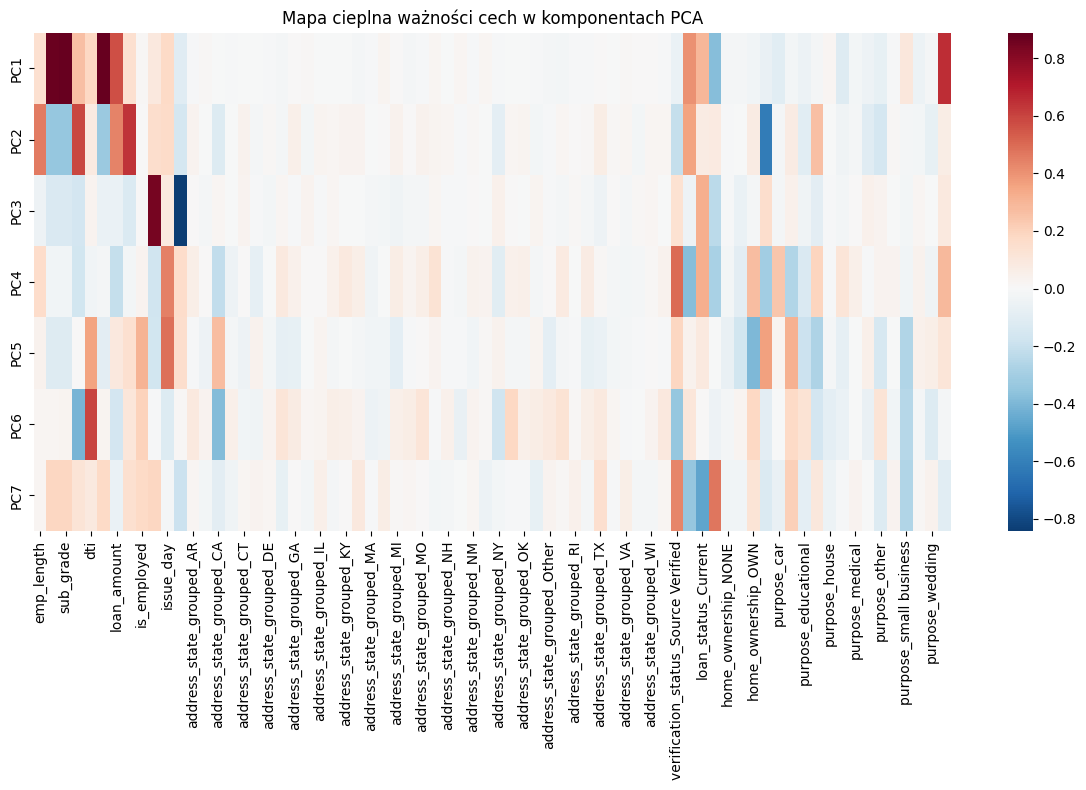

In [ ]:
def analyze_pca_feature_importance(pca_model, feature_names, n_components=7):
    
    loadings = pca_model.components_.T * np.sqrt(pca_model.explained_variance_)
    
    loadings_df = pd.DataFrame(
        loadings,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=feature_names
    )
    
    print("Najważniejsze cechy dla każdego komponentu:")
    for i in range(n_components):
        pc_name = f'PC{i+1}'
        important_features = loadings_df[pc_name].abs().nlargest(5)
        print(f"\n{pc_name} (wyjaśnia {pca.explained_variance_ratio_[i]:.1%} wariancji):")
        for feature, loading in important_features.items():
            print(f"  {feature}: {loading:.3f}")
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(loadings_df.T, annot=False, fmt=".1f" ,cmap='RdBu_r', center=0)
    plt.title('Mapa cieplna ważności cech w komponentach PCA')
    plt.tight_layout()
    plt.show()
    
    return loadings_df

feature_names = X.columns.tolist()  
loadings_df = analyze_pca_feature_importance(pca, feature_names)


Możemy zmniejszyć ilość komponentów do 40 zachowując prawie 100% informacji albo zmniejszyć ilość do 7 zachowując ponad 95% informacji.

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 72 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   emp_length                           38576 non-null  float64
 1   grade                                38576 non-null  float64
 2   sub_grade                            38576 non-null  float64
 3   annual_income                        38576 non-null  float64
 4   dti                                  38576 non-null  float64
 5   int_rate                             38576 non-null  float64
 6   loan_amount                          38576 non-null  float64
 7   total_acc                            38576 non-null  float64
 8   is_employed                          38576 non-null  float64
 9   issue_month                          38576 non-null  int32  
 10  issue_day                            38576 non-null  int32  
 11  date_diff                   

# Modele

In [21]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [22]:
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

In [26]:
def model_eval(X, labels):
    unique_labels = set(labels)
    if len(unique_labels) < 2 or (len(unique_labels) == 1 and -1 in unique_labels):
        return {'silhouette': None, 'calinski': None, 'davies': None}
    
    silhouette = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    
    print(f'silhouette: {silhouette:.3f}, calinski: {calinski:.3f}, davies: {davies:.3f}')
    
    return {'silhouette': silhouette, 'calinski': calinski, 'davies': davies}

In [30]:
def find_optimal_clusters_multi_algorithm(X, algorithms=None, max_k=20):
    """
    Evaluate multiple clustering algorithms across different k values
    """
    
    if algorithms is None:
        algorithms = {
            'KMeans': KMeans,
            'AgglomerativeClustering': AgglomerativeClustering,
            'GaussianMixture': GaussianMixture,
             'SpectralClustering': SpectralClustering
        }
    
    results = {}
    k_range = range(2, max_k + 1)
    
    print("Multi-Algorithm Cluster Evaluation:")
    print("=" * 60)
    
    for algo_name, algo_class in algorithms.items():
        print(f"\n{algo_name} Results:")
        print("-" * 40)
        
        silhouette_scores = []
        calinski_scores = []
        davies_scores = []
        inertias = []
        
        for k in k_range:
            print(f"\nK = {k}:")
            
            try:
                # Handle different algorithm parameter names
                if algo_name == 'GaussianMixture':
                    model = algo_class(n_components=k, random_state=42)
                    model.fit(X)
                    labels = model.predict(X)
                    inertia = None  # GMM doesn't have inertia
                elif algo_name == 'AgglomerativeClustering':
                    model = algo_class(n_clusters=k)
                    labels = model.fit_predict(X)
                    inertia = getattr(model, 'inertia_', None)
                else:
                    model = algo_class(n_clusters=k, random_state=42)
                    labels = model.fit_predict(X)
                    inertia = getattr(model, 'inertia_', None)
                
                # Evaluate clustering
                metrics = model_eval(X, labels)
                
                silhouette_scores.append(metrics['silhouette'])
                calinski_scores.append(metrics['calinski'])
                davies_scores.append(metrics['davies'])
                inertias.append(inertia)
                
            except Exception as e:
                print(f"Error with {algo_name} at k={k}: {e}")
                silhouette_scores.append(None)
                calinski_scores.append(None)
                davies_scores.append(None)
                inertias.append(None)
        
        # Store results
        results[algo_name] = {
            'silhouette_scores': silhouette_scores,
            'calinski_scores': calinski_scores,
            'davies_scores': davies_scores,
            'inertias': inertias
        }
    
    # Plot comparison
    plot_algorithm_comparison(results, k_range)
    
    # Find best k for each algorithm and metric
    print_best_k_summary(results, k_range)
    
    return results

def plot_algorithm_comparison(results, k_range):
    """Plot comparison of different algorithms across metrics"""
    
    algorithms = list(results.keys())
    n_algorithms = len(algorithms)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    metrics = ['silhouette_scores', 'calinski_scores', 'davies_scores', 'inertias']
    titles = ['Silhouette Score (Higher is Better)', 
              'Calinski-Harabasz Score (Higher is Better)',
              'Davies-Bouldin Score (Lower is Better)', 
              'Inertia/WCSS (Lower is Better)']
    
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[i]
        
        for j, algo in enumerate(algorithms):
            scores = results[algo][metric]
            # Filter out None values
            valid_k = [k for k, score in zip(k_range, scores) if score is not None]
            valid_scores = [score for score in scores if score is not None]
            
            if valid_scores:  # Only plot if we have valid scores
                ax.plot(valid_k, valid_scores, marker='o', 
                       label=algo, color=colors[j % len(colors)])
        
        ax.set_title(title)
        ax.set_xlabel('Number of clusters (k)')
        ax.set_ylabel(title.split('(')[0].strip())
        ax.legend()
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

def print_best_k_summary(results, k_range):
    """Print summary of best k for each algorithm and metric"""
    
    print(f"\n{'='*60}")
    print("BEST K SUMMARY")
    print(f"{'='*60}")
    
    for algo in results.keys():
        print(f"\n{algo}:")
        
        # Silhouette (higher is better)
        sil_scores = results[algo]['silhouette_scores']
        valid_sil = [(k, score) for k, score in zip(k_range, sil_scores) if score is not None]
        if valid_sil:
            best_k_sil = max(valid_sil, key=lambda x: x[1])
            print(f"  Best k (Silhouette): {best_k_sil[0]} (score: {best_k_sil[1]:.3f})")
        
        # Calinski-Harabasz (higher is better)
        cal_scores = results[algo]['calinski_scores']
        valid_cal = [(k, score) for k, score in zip(k_range, cal_scores) if score is not None]
        if valid_cal:
            best_k_cal = max(valid_cal, key=lambda x: x[1])
            print(f"  Best k (Calinski-Harabasz): {best_k_cal[0]} (score: {best_k_cal[1]:.3f})")
        
        # Davies-Bouldin (lower is better)
        dav_scores = results[algo]['davies_scores']
        valid_dav = [(k, score) for k, score in zip(k_range, dav_scores) if score is not None]
        if valid_dav:
            best_k_dav = min(valid_dav, key=lambda x: x[1])
            print(f"  Best k (Davies-Bouldin): {best_k_dav[0]} (score: {best_k_dav[1]:.3f})")


Multi-Algorithm Cluster Evaluation:

KMeans Results:
----------------------------------------

K = 2:
silhouette: 0.206, calinski: 8936.916, davies: 1.911

K = 3:
silhouette: 0.140, calinski: 7314.574, davies: 2.006

K = 4:
silhouette: 0.122, calinski: 6036.927, davies: 2.005

K = 5:
silhouette: 0.117, calinski: 5445.963, davies: 1.965

K = 6:
silhouette: 0.132, calinski: 5304.644, davies: 1.819

K = 7:
silhouette: 0.126, calinski: 4985.498, davies: 1.738

K = 8:
silhouette: 0.128, calinski: 4751.454, davies: 1.697

K = 9:
silhouette: 0.122, calinski: 4445.411, davies: 1.669

K = 10:
silhouette: 0.123, calinski: 4232.559, davies: 1.729

K = 11:
silhouette: 0.118, calinski: 4010.756, davies: 1.713

K = 12:
silhouette: 0.122, calinski: 3858.729, davies: 1.685

K = 13:
silhouette: 0.120, calinski: 3685.253, davies: 1.670

K = 14:
silhouette: 0.120, calinski: 3560.917, davies: 1.668

K = 15:
silhouette: 0.120, calinski: 3434.553, davies: 1.632

K = 16:
silhouette: 0.117, calinski: 3315.681

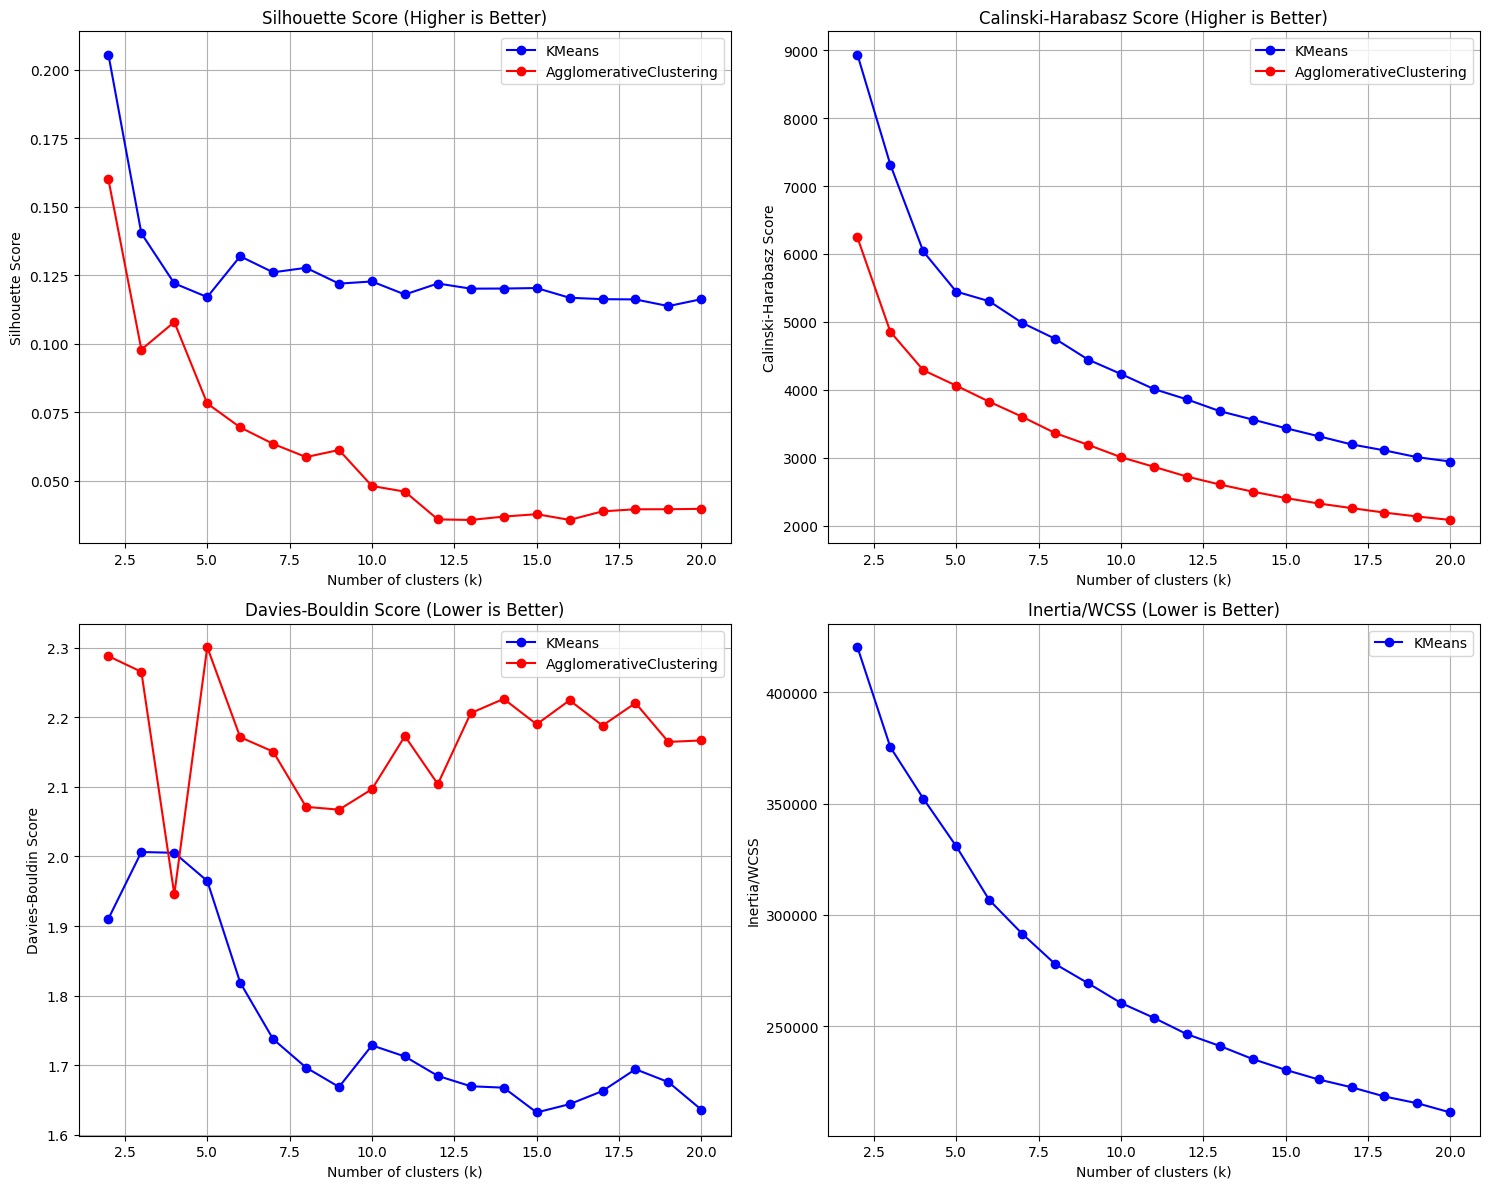


BEST K SUMMARY

KMeans:
  Best k (Silhouette): 2 (score: 0.206)
  Best k (Calinski-Harabasz): 2 (score: 8936.916)
  Best k (Davies-Bouldin): 15 (score: 1.632)

AgglomerativeClustering:
  Best k (Silhouette): 2 (score: 0.160)
  Best k (Calinski-Harabasz): 2 (score: 6243.216)
  Best k (Davies-Bouldin): 4 (score: 1.946)

GaussianMixture:


In [ ]:
algorithms = {
            'KMeans': KMeans,
            'AgglomerativeClustering': AgglomerativeClustering,
            'GaussianMixture': GaussianMixture
        }
        
results = find_optimal_clusters_multi_algorithm(X_pca, max_k=20, algorithms=algorithms)
# błą dla gmm poprawiony

Multi-Algorithm Cluster Evaluation:

GaussianMixture Results:
----------------------------------------

K = 2:
silhouette: 0.212, calinski: 7797.162, davies: 1.956

K = 3:
silhouette: 0.129, calinski: 6507.984, davies: 2.099

K = 4:
silhouette: 0.101, calinski: 4684.021, davies: 2.404

K = 5:
silhouette: 0.085, calinski: 4002.354, davies: 2.235

K = 6:
silhouette: 0.084, calinski: 3805.265, davies: 2.201

K = 7:
silhouette: 0.082, calinski: 3605.650, davies: 2.034

K = 8:
silhouette: 0.081, calinski: 3646.245, davies: 1.940

K = 9:
silhouette: 0.049, calinski: 2937.710, davies: 2.153

K = 10:
silhouette: 0.046, calinski: 2760.885, davies: 2.164

K = 11:
silhouette: 0.035, calinski: 2657.523, davies: 2.263

K = 12:
silhouette: 0.053, calinski: 2790.671, davies: 1.989

K = 13:
silhouette: 0.047, calinski: 2582.103, davies: 2.088

K = 14:
silhouette: 0.047, calinski: 2453.742, davies: 2.213

K = 15:
silhouette: 0.044, calinski: 2380.764, davies: 2.112

K = 16:
silhouette: 0.031, calinski:

C:\Users\alapr\AppData\Local\Temp\ipykernel_22752\1824094329.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


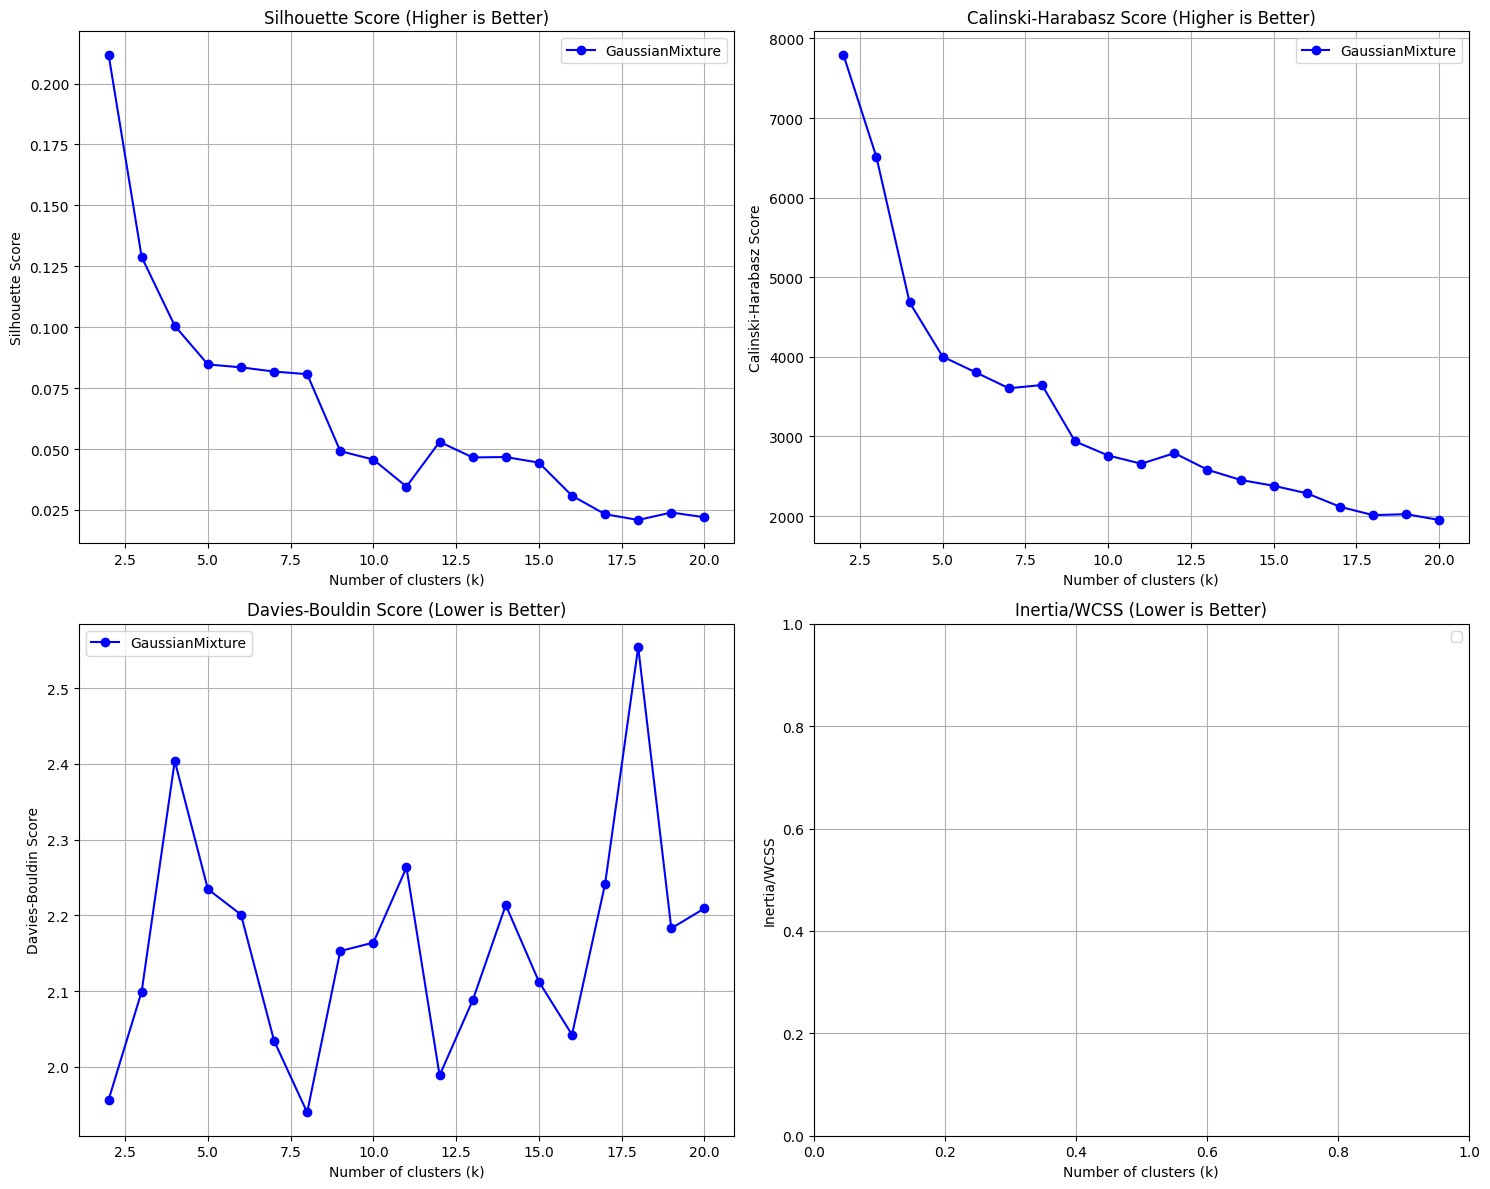


BEST K SUMMARY

GaussianMixture:
  Best k (Silhouette): 2 (score: 0.212)
  Best k (Calinski-Harabasz): 2 (score: 7797.162)
  Best k (Davies-Bouldin): 8 (score: 1.940)


In [ ]:
#można wywołać bez tego
algorithms2 = {
            'GaussianMixture': GaussianMixture
        }
        
results2 = find_optimal_clusters_multi_algorithm(X_pca, max_k=20, algorithms=algorithms2)


In [31]:
def plot_tsne_umap_clusters(X_tsne, X_umap, labels, title_tsne='t-SNE', title_umap='UMAP'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # t-SNE
    sc1 = axes[0].scatter(X_tsne[:,0], X_tsne[:,1], c=labels, s=5, alpha=0.6, cmap='Spectral')
    axes[0].set_title(title_tsne)
    plt.colorbar(sc1, ax=axes[0], label='Cluster Label')
    
    # UMAP
    sc2 = axes[1].scatter(X_umap[:,0], X_umap[:,1], c=labels, s=5, alpha=0.6, cmap='Spectral')
    axes[1].set_title(title_umap)
    plt.colorbar(sc2, ax=axes[1], label='Cluster Label')
    
    plt.tight_layout()
    plt.show()


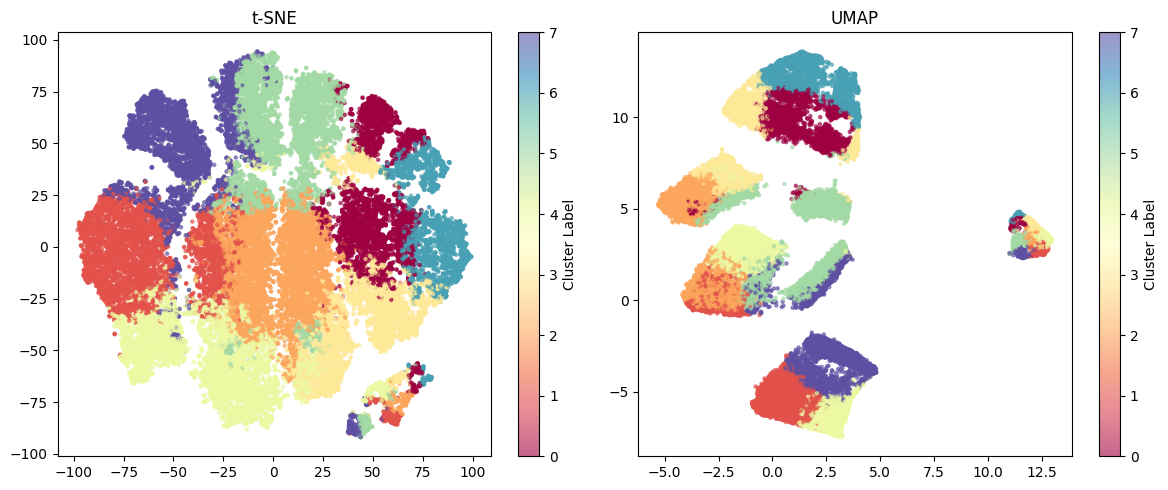

In [28]:
kmeans = KMeans(n_clusters=8, init = 'k-means++', n_init=10, random_state=42).fit(X)
labels_kmeans = kmeans.labels_
plot_tsne_umap_clusters(X_tsne, X_umap, labels_kmeans)

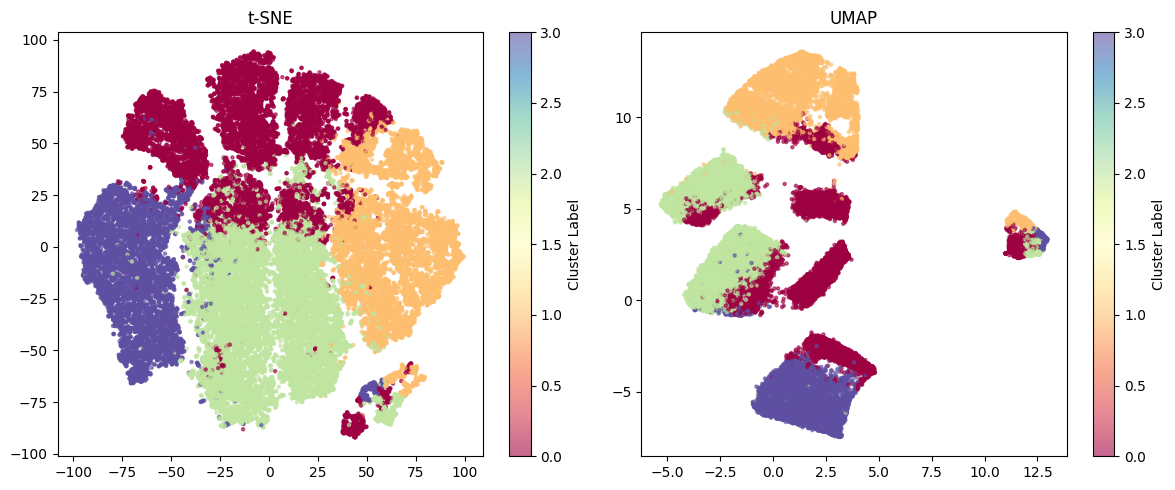

In [99]:
agglomerative = AgglomerativeClustering(n_clusters=4).fit(X)
labels_agglomerative = agglomerative.labels_
plot_tsne_umap_clusters(X_tsne, X_umap, labels_agglomerative)

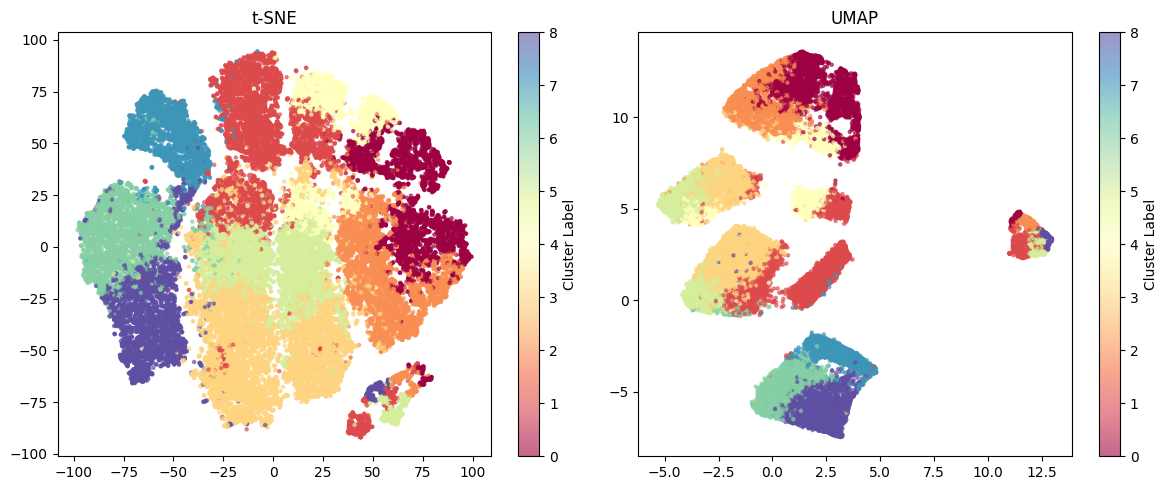

In [29]:
agglomerative = AgglomerativeClustering(n_clusters=9).fit(X)
labels_agglomerative = agglomerative.labels_
plot_tsne_umap_clusters(X_tsne, X_umap, labels_agglomerative)

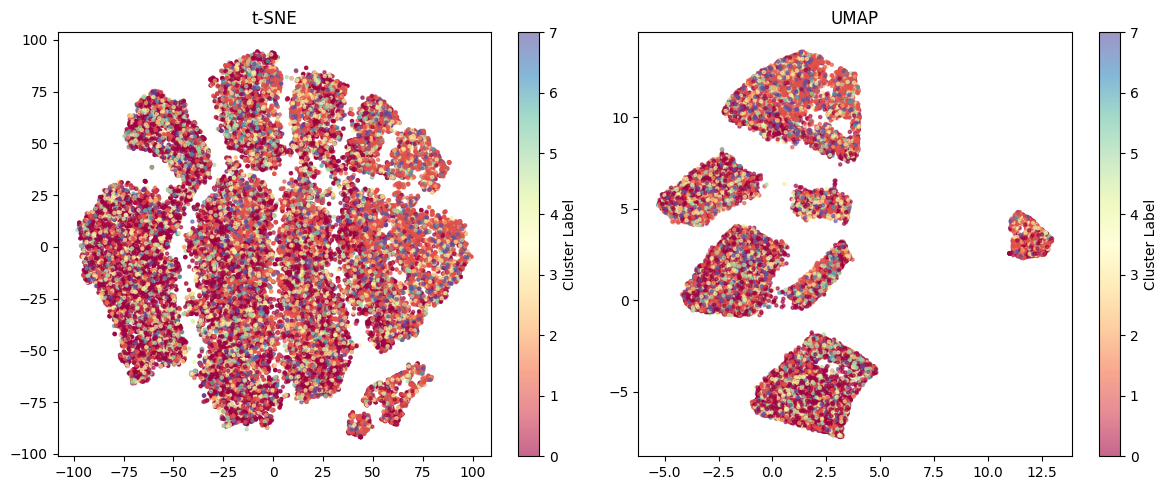

In [30]:
gaussian = GaussianMixture(n_components = 8, random_state=42).fit(X)
labels_gaussian = gaussian.predict(X)
plot_tsne_umap_clusters(X_tsne, X_umap, labels_gaussian)

In [ ]:
from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.1)
labels = optics.fit_predict(X)

KeyboardInterrupt: 

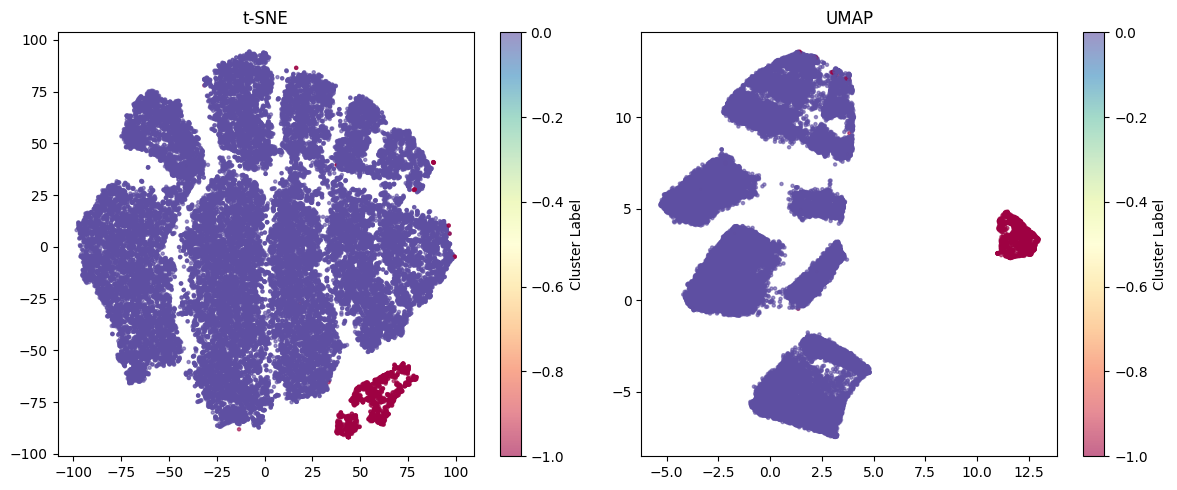

In [40]:
plot_tsne_umap_clusters(X_tsne, X_umap, labels)

In [27]:
import itertools
param_grid = {
    'min_samples': [5, 10, 15],
    'xi': [0.05, 0.1, 0.2]
}

results = []

for min_samples, xi in itertools.product(param_grid['min_samples'], param_grid['xi']):
    optics = OPTICS(min_samples=min_samples, xi=xi)
    labels = optics.fit_predict(X_pca)
    scores = model_eval(X_pca, labels)
    results.append({'min_samples': min_samples, 'xi': xi, **scores})

for res in results:
    print(res)

silhouette: -0.593, calinski: 5.673, davies: 1.386
silhouette: -0.546, calinski: 4.862, davies: 1.377
silhouette: -0.100, calinski: 3.256, davies: 1.337
silhouette: -0.353, calinski: 5.275, davies: 2.051
{'min_samples': 5, 'xi': 0.05, 'silhouette': np.float64(-0.5933337974420104), 'calinski': np.float64(5.672803919088363), 'davies': np.float64(1.3859182176356823)}
{'min_samples': 5, 'xi': 0.1, 'silhouette': np.float64(-0.5455203871718248), 'calinski': np.float64(4.86232577669272), 'davies': np.float64(1.3772976828764778)}
{'min_samples': 5, 'xi': 0.2, 'silhouette': np.float64(-0.09971928801175), 'calinski': np.float64(3.2564698316015086), 'davies': np.float64(1.337090429875909)}
{'min_samples': 10, 'xi': 0.05, 'silhouette': np.float64(-0.35257469822123216), 'calinski': np.float64(5.2754759150154324), 'davies': np.float64(2.05114411535521)}
{'min_samples': 10, 'xi': 0.1, 'silhouette': None, 'calinski': None, 'davies': None}
{'min_samples': 10, 'xi': 0.2, 'silhouette': None, 'calinski': 

In [28]:
optics = OPTICS(min_samples=5, xi=0.02, min_cluster_size=0.1)
labels = optics.fit_predict(X)

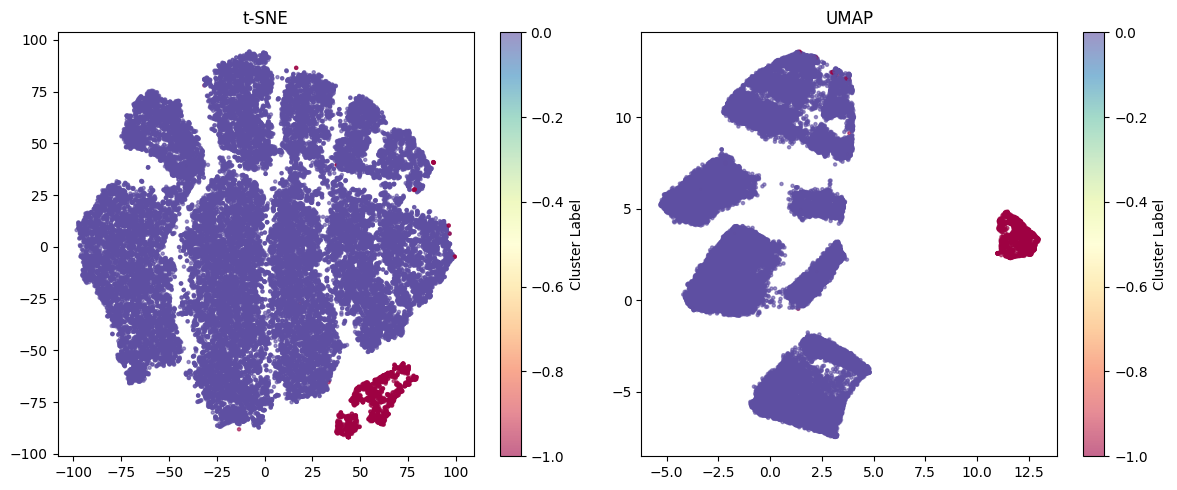

In [34]:
plot_tsne_umap_clusters(X_tsne, X_umap, labels)

In [37]:
optics = OPTICS(min_samples=5, xi=0.02, min_cluster_size=0.02, max_eps = np.inf) #5
labels = optics.fit_predict(X)

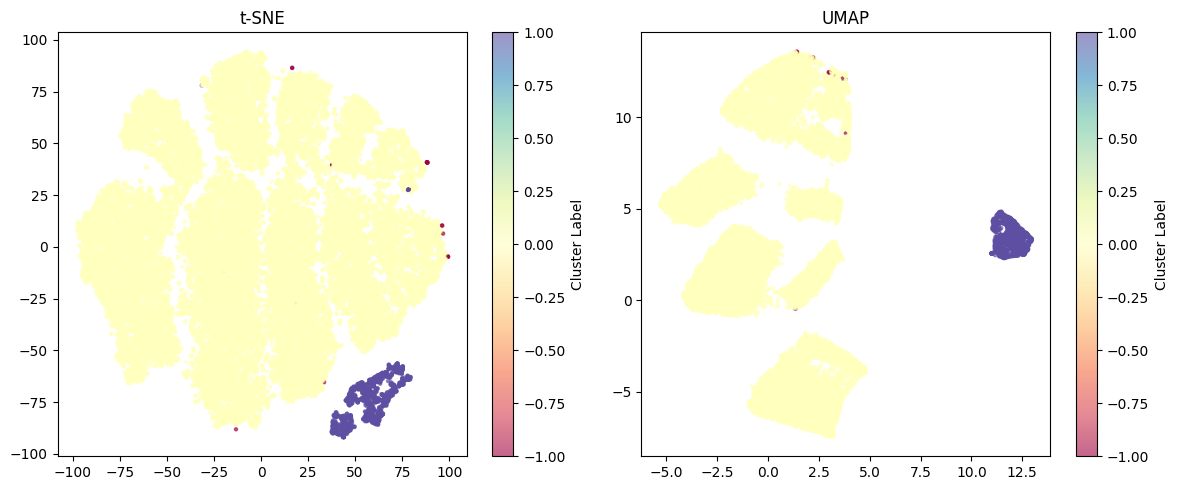

In [38]:
plot_tsne_umap_clusters(X_tsne, X_umap, labels)